In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os
import json
import numpy as np

In [54]:
files = glob(r"Li-Control\co2dot_data\*co2response.json")
files

['Li-Control\\co2dot_data\\2026-06-19_11-19-14_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-19_12-15-08_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-19_12-15-37_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-19_12-34-02_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-19_13-01-38_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-24_14-46-48_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-25_11-29-15_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-25_16-44-56_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-25_16-57-28_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-29_09-33-01_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-29_09-33-23_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-29_17-43-04_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-30_08-48-26_co2response.json',
 'Li-Control\\co2dot_data\\2026-06-30_08-52-59_co2response.json']

In [59]:
file = files[-1]
with open(file, "r") as f:
        data = json.load(f)
        try:
            metadata = {
                "experiment_start": data["experiment_start"],
                "co2_concentration": data["co2_s_values"],
                # "stabilise_tol": data["stabilise_tol"],
                # "stabilise_timeout": data["stabilise_timeout_s"],
                # "extra_wait_s": data["extra_wait_s"],
                "experiment_end": data["experiment_end"]
            }
                    
        except Exception as e:
            print(f"Error processing file {file}: {e}")

        df = pd.DataFrame(data["records"])
        df["timestamp"] = pd.to_datetime(df["timestamp"])

In [60]:
# Expand the dict-valued "licor" and "co2dot" columns into flat columns.
# licor is a flat dict; co2dot is nested (status / spec_flash / env) -> flatten with sep="_".
# Prefixes keep names unique (e.g. licor_CO2_s vs co2_s_setpoint) and mark provenance.
licor_expanded = pd.json_normalize(df["licor"], sep="_").add_prefix("licor_")
co2dot_expanded = pd.json_normalize(df["co2dot"], sep="_").add_prefix("co2dot_")

df = pd.concat(
    [
        df.drop(columns=["licor", "co2dot"]).reset_index(drop=True),
        licor_expanded.reset_index(drop=True),
        co2dot_expanded.reset_index(drop=True),
    ],
    axis=1,
)
df

,timestamp,co2_s_setpoint,note,temp,rh,rep,measurement,licor_TIME,licor_DIAG,licor_CO2_s,...,co2dot_spec_flash_diff_f5_555,co2dot_spec_flash_diff_f6_590,co2dot_spec_flash_diff_f7_630,co2dot_spec_flash_diff_f8_680,co2dot_spec_flash_diff_clear,co2dot_spec_flash_diff_nir,co2dot_env_T,co2dot_env_P,co2dot_env_RH,co2dot_env_Gas
0,2026-06-30 08:53:00,300,,22,40,0,0,1.782975e+09,18,380.036,...,251,342,352,218,800,85,24.22,1022.77,38.51,9176
1,2026-06-30 08:53:22,300,,22,40,0,1,1.782975e+09,18,380.019,...,252,343,352,217,800,85,24.22,1022.95,38.51,12932
2,2026-06-30 08:53:43,300,,22,40,0,2,1.782975e+09,18,379.949,...,251,342,353,217,799,86,24.22,1022.68,38.50,16347
3,2026-06-30 08:54:05,300,,22,40,0,3,1.782975e+09,18,380.030,...,251,342,352,217,800,85,24.20,1022.87,38.51,19440
4,2026-06-30 08:54:26,300,,22,40,0,4,1.782975e+09,18,379.932,...,251,342,353,218,800,86,24.21,1022.82,38.50,22167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,2026-06-30 12:14:36,400,,23,70,2,3,1.782987e+09,18,378.918,...,258,349,356,222,802,85,25.08,1022.45,51.82,44759
430,2026-06-30 12:14:57,400,,23,70,2,4,1.782987e+09,18,377.471,...,258,349,356,222,802,84,25.09,1022.18,51.82,44331
431,2026-06-30 12:15:19,400,,23,70,2,5,1.782987e+09,18,377.073,...,258,348,356,222,802,85,25.08,1022.41,51.80,43820
432,2026-06-30 12:39:30,300,,31,40,0,0,1.782989e+09,18,376.923,...,258,350,357,222,801,85,25.07,1021.85,42.49,9349


In [107]:
print(df["rh"].iloc[50:100])

50    40
51    40
52    40
53    40
54    40
55    40
56    40
57    40
58    40
59    40
60    40
61    40
62    40
63    40
64    40
65    40
66    40
67    40
68    40
69    40
70    40
71    40
72    55
73    55
74    55
75    55
76    55
77    55
78    55
79    55
80    55
81    55
82    55
83    55
84    55
85    55
86    55
87    55
88    55
89    55
90    55
91    55
92    55
93    55
94    55
95    55
96    55
97    55
98    55
Name: rh, dtype: int64


In [108]:
print(df["co2dot_env_RH"].iloc[50:100])

50    39.17
51    39.18
52    39.19
53    39.20
54    39.13
55    39.19
56    39.18
57    39.18
58    39.18
59    39.17
60    39.10
61    39.14
62    39.15
63    39.13
64    39.12
65    39.12
66    39.04
67    39.09
68    39.12
69    39.11
70    39.11
71    39.11
72    39.02
73    38.97
74    38.99
75    38.97
76    38.97
77    38.98
78    38.90
79    38.94
80    38.96
81    38.97
82    38.96
83    38.97
84    38.87
85    38.95
86    38.97
87    38.96
88    38.96
89    38.94
90    38.88
91    38.93
92    38.93
93    38.94
94    38.94
95    38.94
96    38.87
97    38.91
98    38.93
Name: co2dot_env_RH, dtype: float64


Text(0.5, 1.0, 'Comparison Licor vs CO2Dot')

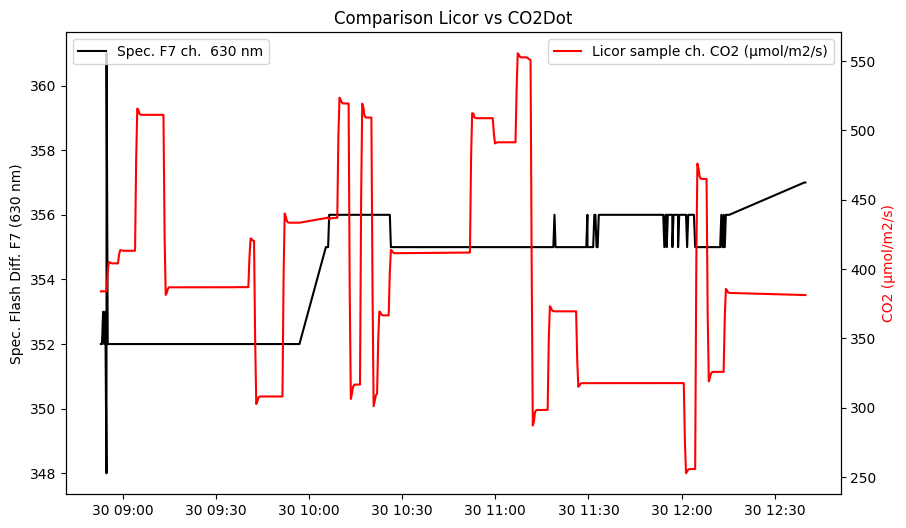

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["timestamp"], df["co2dot_spec_flash_diff_f7_630"],color="k", label="Spec. F7 ch.  630 nm")
ax2 = ax.twinx()
ax2.plot(df["timestamp"], df["licor_CO2_s_d"], color="r", label="Licor sample ch. CO2 (µmol/m2/s)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.xlabel("Time")
ax.set_ylabel("Spec. Flash Diff. F7 (630 nm)",color="k")
ax2.set_ylabel("CO2 (µmol/m2/s)",color="r")
plt.title("Comparison Licor vs CO2Dot")

Text(0.5, 1.0, 'Environmental conditions during measurement')

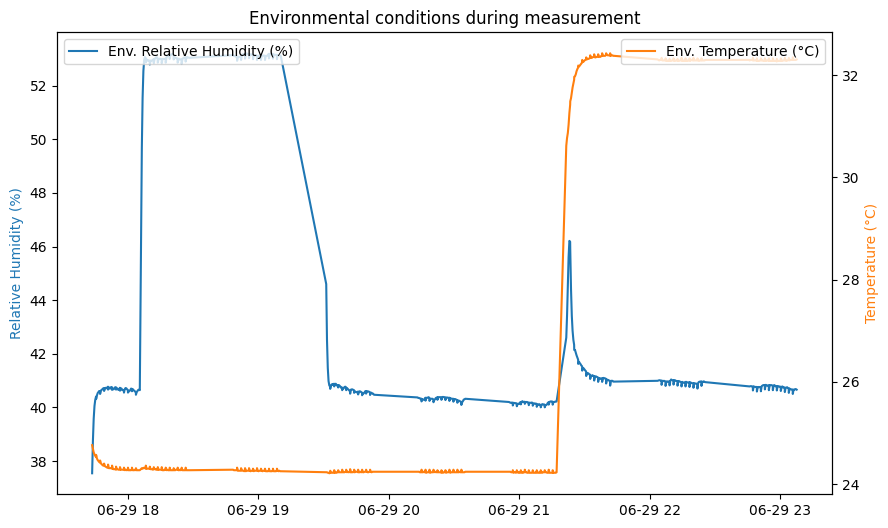

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["timestamp"], df["co2dot_env_RH"],color="C00", label="Env. Relative Humidity (%)")
ax2 = ax.twinx()
ax2.plot(df["timestamp"], df["co2dot_env_T"], color="C01", label="Env. Temperature (°C)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.xlabel("Time")
ax.set_ylabel("Relative Humidity (%)",color="C00")
ax2.set_ylabel("Temperature (°C)",color="C01")
plt.title("Environmental conditions during measurement")

Total samples: 648
Training samples: 518, Testing samples: 130
Linear regression
  MAE : 22.3
  RMSE: 36.7
  R^2 : 0.7776
Coefficients: {'X1': np.float64(2.9418875528765835), 'X2': np.float64(-1.5199114706127823)}
Intercept: -22028.50975938932


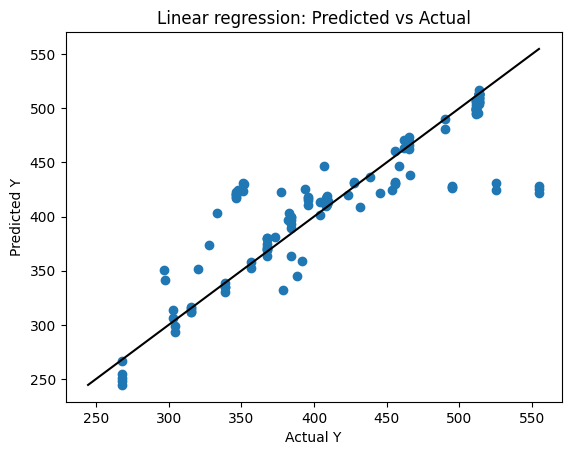

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = df[["co2dot_spec_flash_diff_f1_415","co2dot_spec_flash_diff_f2_445","co2dot_spec_flash_diff_f3_480","co2dot_spec_flash_diff_f4_515","co2dot_spec_flash_diff_f5_555","co2dot_spec_flash_diff_f6_590","co2dot_spec_flash_diff_f7_630","co2dot_spec_flash_diff_f8_680","co2dot_spec_flash_diff_clear","co2dot_spec_flash_diff_nir","co2dot_env_T","co2dot_env_P","co2dot_env_RH","co2dot_env_Gas"]]
y = df["licor_CO2_s_d"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficients:", dict(zip(["X1", "X2"], lin.coef_)))
print("Intercept:", lin.intercept_)

plt.figure()
plt.scatter(y_test, pred)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims,"k")  # y=x reference
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.title("Linear regression: Predicted vs Actual")
plt.show()
